In [5]:
import pandas as pd
import numpy as np
import os

import plotly.express as px
import plotly.graph_objects as go

# from prophet import Prophet

print("Libraries Imported Successfully ✅")



Libraries Imported Successfully ✅


In [6]:
# ================================
# Step 2: Load Dataset
# ================================

# File path to raw data
file_path = "../data/raw/covid_19_clean_complete.csv"

# Load dataset
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")

# Preview first 5 rows
df.head()


Dataset Loaded Successfully ✅


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [4]:
!pip install prophet


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 11.0 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 3/5 [cmdstanpy]  WARNING: The scripts install_cmdstan and install_cxx_toolchain are installed in '/home/01eab4af-7164-4655-a9f6-3e3143c902ae/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [prophet]━━━━ 4/5 [prophet]


In [7]:
# ================================
# Step 4: Clean Column Names
# ================================

# Clean column names
df.columns = df.columns.str.strip() \
                       .str.replace("/", "_") \
                       .str.replace(" ", "_") \
                       .str.lower()

print("Updated Column Names:")

df.columns


Updated Column Names:


Index(['province_state', 'country_region', 'lat', 'long', 'date', 'confirmed',
       'deaths', 'recovered', 'active', 'who_region'],
      dtype='object')

In [8]:
# ================================
# Step 5: Convert Date Column
# ================================

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

print("Date Converted Successfully ✅")

df.dtypes


Date Converted Successfully ✅


/tmp/ipykernel_445/486057656.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], dayfirst=True)


province_state            object
country_region            object
lat                      float64
long                     float64
date              datetime64[ns]
confirmed                  int64
deaths                     int64
recovered                  int64
active                     int64
who_region                object
dtype: object

In [9]:
# ================================
# Step 6: Handle Missing Values
# ================================

df['province_state'] = df['province_state'].fillna("Unknown")

print("Missing Values Check:")

df.isnull().sum()


Missing Values Check:


province_state    0
country_region    0
lat               0
long              0
date              0
confirmed         0
deaths            0
recovered         0
active            0
who_region        0
dtype: int64

In [10]:
# ================================
# Step 7: Remove Duplicates
# ================================

before = df.shape[0]

df = df.drop_duplicates()

after = df.shape[0]

print("Duplicates Removed:", before - after)


Duplicates Removed: 0


In [11]:
# ================================
# Step 8: Save Cleaned Data
# ================================

output_path = "../data/processed/cleaned_covid_data.csv"

df.to_csv(output_path, index=False)

print("Cleaned Data Saved Successfully ✅")


Cleaned Data Saved Successfully ✅


In [12]:
# ================================
# Step 9: Load Cleaned Data
# ================================

cleaned_path = "../data/processed/cleaned_covid_data.csv"

df = pd.read_csv(cleaned_path)

# Convert date again (safe practice)
df['date'] = pd.to_datetime(df['date'])

print("Cleaned Data Loaded Successfully ✅")

df.head()


Cleaned Data Loaded Successfully ✅


,province_state,country_region,lat,long,date,confirmed,deaths,recovered,active,who_region
0,Unknown,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Unknown,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,Unknown,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,Unknown,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,Unknown,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [13]:
# ================================
# Step 10: Group by Date
# ================================

daily_df = df.groupby('date')[[
    'confirmed',
    'deaths',
    'recovered',
    'active'
]].sum().reset_index()

print("Daily Aggregated Data Created ✅")

daily_df.head()


Daily Aggregated Data Created ✅


,date,confirmed,deaths,recovered,active
0,2020-01-22,555,17,28,510
1,2020-01-23,654,18,30,606
2,2020-01-24,941,26,36,879
3,2020-01-25,1434,42,39,1353
4,2020-01-26,2118,56,52,2010


In [14]:
# ================================
# Step 11: Save Daily Data
# ================================

daily_output_path = "../data/processed/daily_global_data.csv"

daily_df.to_csv(daily_output_path, index=False)

print("Daily Data Saved Successfully ✅")


Daily Data Saved Successfully ✅


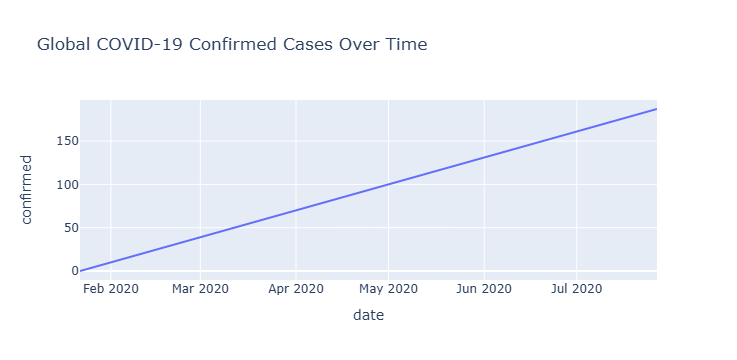

In [15]:
# ================================
# Step 12: Confirmed Cases Trend
# ================================

fig = px.line(
    daily_df,
    x='date',
    y='confirmed',
    title="Global COVID-19 Confirmed Cases Over Time"
)

fig.show()


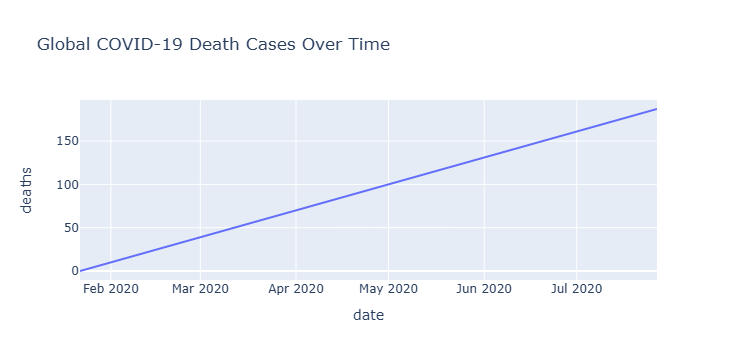

In [16]:
# ================================
# Step 13: Death Trend Plot
# ================================

fig = px.line(
    daily_df,
    x='date',
    y='deaths',
    title="Global COVID-19 Death Cases Over Time"
)

fig.show()


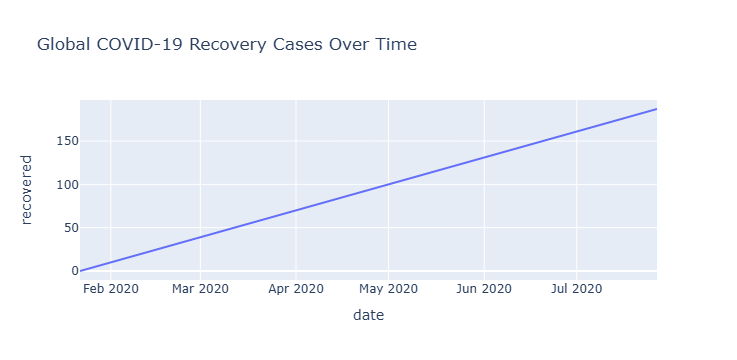

In [17]:
# ================================
# Step 14: Recovery Trend Plot
# ================================

fig = px.line(
    daily_df,
    x='date',
    y='recovered',
    title="Global COVID-19 Recovery Cases Over Time"
)

fig.show()


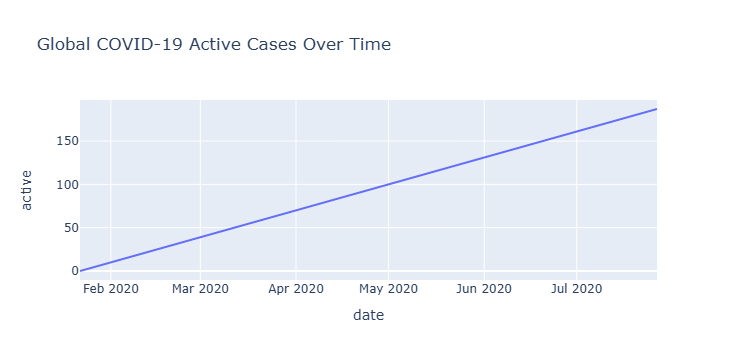

In [18]:
# ================================
# Step 15: Active Cases Plot
# ================================

fig = px.line(
    daily_df,
    x='date',
    y='active',
    title="Global COVID-19 Active Cases Over Time"
)

fig.show()


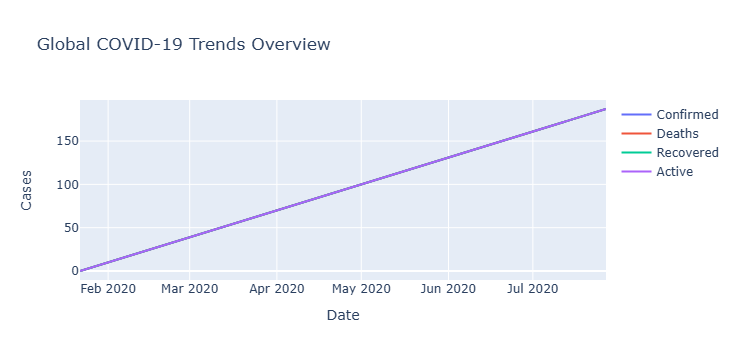

In [19]:
# ================================
# Step 16: Combined Trend Plot
# ================================

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=daily_df['date'],
    y=daily_df['confirmed'],
    mode='lines',
    name='Confirmed'
))

fig.add_trace(go.Scatter(
    x=daily_df['date'],
    y=daily_df['deaths'],
    mode='lines',
    name='Deaths'
))

fig.add_trace(go.Scatter(
    x=daily_df['date'],
    y=daily_df['recovered'],
    mode='lines',
    name='Recovered'
))

fig.add_trace(go.Scatter(
    x=daily_df['date'],
    y=daily_df['active'],
    mode='lines',
    name='Active'
))

fig.update_layout(
    title="Global COVID-19 Trends Overview",
    xaxis_title="Date",
    yaxis_title="Cases"
)

fig.show()


In [20]:
# ================================
# Step 17: Save Confirmed Plot
# ================================

plot_path = "../outputs/plots/confirmed_cases_trend.html"

fig = px.line(
    daily_df,
    x='date',
    y='confirmed',
    title="Global COVID-19 Confirmed Cases Over Time"
)

fig.write_html(plot_path)

print("Plot Saved Successfully ✅")


Plot Saved Successfully ✅


In [21]:
# ================================
# Step 18: Prepare Data for Prophet
# ================================

# Prophet requires column names: ds and y
prophet_df = daily_df[['date', 'confirmed']]

prophet_df = prophet_df.rename(columns={
    'date': 'ds',
    'confirmed': 'y'
})

print("Prophet Dataset Ready ✅")

prophet_df.head()


Prophet Dataset Ready ✅


,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118


In [22]:
# ================================
# Step 19: Import Prophet
# ================================

from prophet import Prophet

print("Prophet Imported Successfully ✅")


Prophet Imported Successfully ✅


In [23]:
# ================================
# Step 20: Train Prophet Model
# ================================

model = Prophet()

model.fit(prophet_df)

print("Model Training Completed ✅")


18:50:35 - cmdstanpy - INFO - Chain [1] start processing
18:50:35 - cmdstanpy - INFO - Chain [1] done processing


Model Training Completed ✅


In [24]:
# ================================
# Step 21: Create Future Dates
# ================================

future = model.make_future_dataframe(periods=7)

print("Future Dates Created ✅")

future.tail()


Future Dates Created ✅


,ds
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02
194,2020-08-03


In [25]:
# ================================
# Step 22: Forecast Future Cases
# ================================

forecast = model.predict(future)

print("Forecast Generated Successfully ✅")

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()


Forecast Generated Successfully ✅


,ds,yhat,yhat_lower,yhat_upper
190,2020-07-30,1.674392e+07,1.664534e+07,1.685456e+07
191,2020-07-31,1.695911e+07,1.684602e+07,1.706593e+07
192,2020-08-01,1.716677e+07,1.706893e+07,1.728508e+07
193,2020-08-02,1.736430e+07,1.725727e+07,1.747623e+07
194,2020-08-03,1.755889e+07,1.745223e+07,1.768199e+07


Forecast Plot Generated ✅


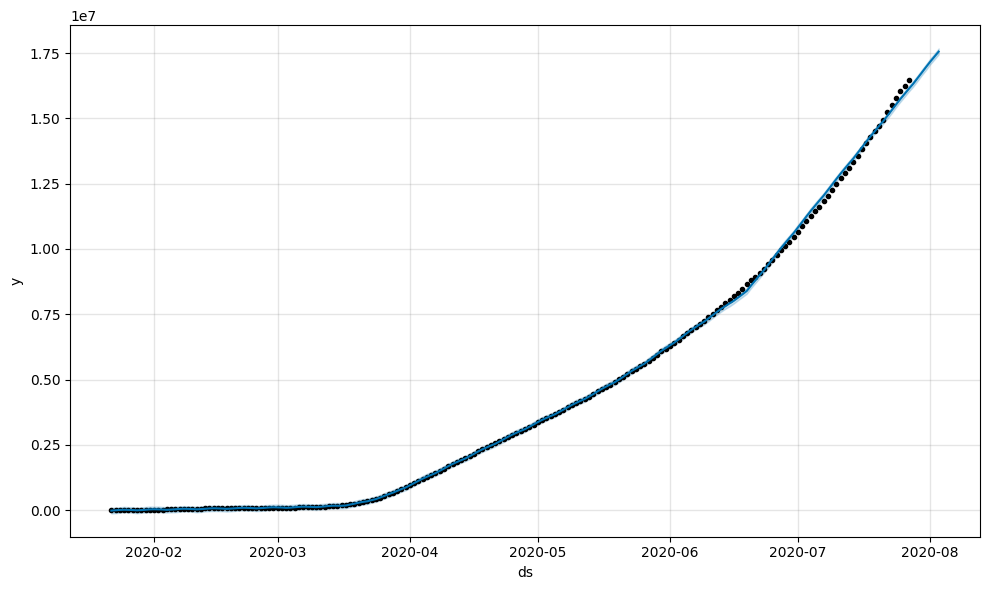

In [26]:
# ================================
# Step 23: Plot Forecast
# ================================

fig1 = model.plot(forecast)

print("Forecast Plot Generated ✅")


Trend Components Displayed ✅


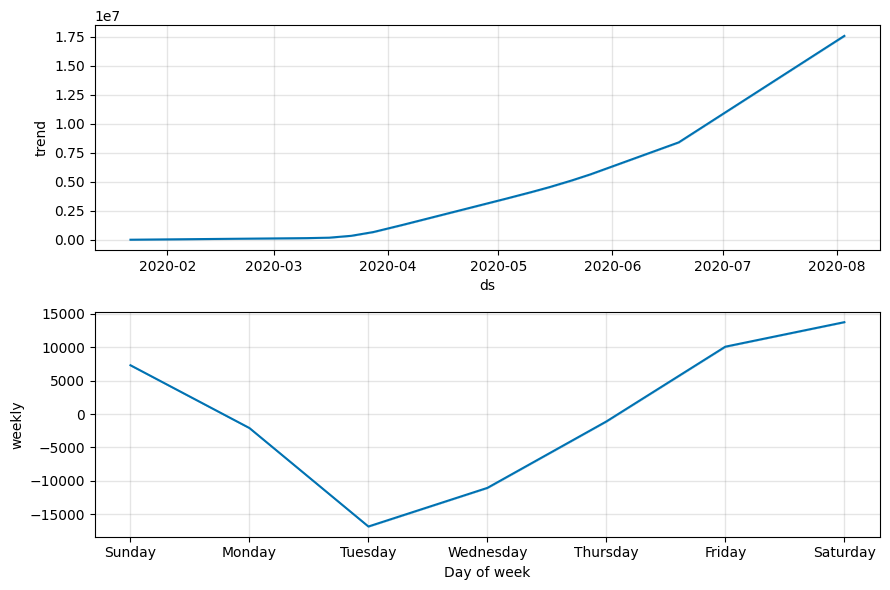

In [27]:
# ================================
# Step 24: Plot Forecast Components
# ================================

fig2 = model.plot_components(forecast)

print("Trend Components Displayed ✅")


In [28]:
# ================================
# Step 25: Save Forecast Data
# ================================

forecast_path = "../outputs/predictions/covid_forecast_7days.csv"

forecast.to_csv(forecast_path, index=False)

print("Forecast Data Saved Successfully ✅")


Forecast Data Saved Successfully ✅


In [29]:
# ================================
# Step 26: Save Forecast Plot
# ================================

forecast_plot_path = "../outputs/predictions/forecast_plot.png"

fig1.savefig(forecast_plot_path)

print("Forecast Plot Saved Successfully ✅")


Forecast Plot Saved Successfully ✅


In [30]:
# ================================
# Step 27: Save Components Plot
# ================================

components_plot_path = "../outputs/predictions/components_plot.png"

fig2.savefig(components_plot_path)

print("Components Plot Saved Successfully ✅")


Components Plot Saved Successfully ✅


In [31]:
# ================================
# Step 28: Save Combined Trend Plot
# ================================

combined_plot_path = "../outputs/plots/global_trend_plot.html"

fig.write_html(combined_plot_path)

print("Combined Trend Plot Saved Successfully ✅")


Combined Trend Plot Saved Successfully ✅


In [1]:
# 📊 COVID-19 Trend Analysis Insights

## Key Observations

1. Confirmed COVID-19 cases show a steady upward trend over time.
2. Death cases increased gradually but at a slower rate than confirmed cases.
3. Recovery cases increased significantly after the initial outbreak phase.
4. Active cases showed fluctuations depending on recovery and death rates.

## Forecast Insights

1. The Prophet model predicts a continued increase in confirmed cases over the next 7 days.
2. The trend component indicates strong long-term growth.
3. Weekly patterns show variation in reporting behavior.

## Conclusion

- COVID-19 cases followed an exponential growth pattern initially.
- Forecast results indicate continued growth in the short term.
- Visualization helps identify trends and understand pandemic progression.


SyntaxError: invalid syntax (3479445889.py, line 5)

In [6]:
import importlib
import preprocessing

importlib.reload(preprocessing)

print("preprocessing module reloaded ✅")


preprocessing module reloaded ✅


In [2]:
import sys
import os
import importlib

src_path = os.path.abspath("../src")

if src_path not in sys.path:
    sys.path.append(src_path)

import forecasting
importlib.reload(forecasting)

print("forecasting module reloaded ✅")


forecasting module reloaded ✅


In [3]:
from data_loader import load_data
from preprocessing import clean_data, create_daily_data
from visualization import plot_confirmed_trend
from forecasting import prepare_prophet_data, train_prophet_model, make_forecast

print("Custom Modules Imported Successfully ✅")


Custom Modules Imported Successfully ✅


In [4]:
# ================================
# Test Full Modular Pipeline
# ================================

file_path = "../data/raw/covid_19_clean_complete.csv"

# Load data
df = load_data(file_path)

# Clean data
df = clean_data(df)

# Create daily dataset
daily_df = create_daily_data(df)

print("Pipeline Working Successfully ✅")

daily_df.head()


Pipeline Working Successfully ✅


/home/01eab4af-7164-4655-a9f6-3e3143c902ae/covid19_trend_analysis/src/preprocessing.py:15: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], dayfirst=True)


,date,confirmed,deaths,recovered,active
0,2020-01-22,555,17,28,510
1,2020-01-23,654,18,30,606
2,2020-01-24,941,26,36,879
3,2020-01-25,1434,42,39,1353
4,2020-01-26,2118,56,52,2010


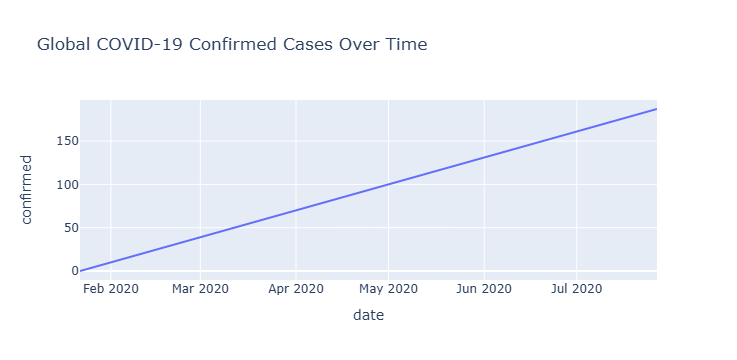

In [5]:
# ================================
# Test Visualization
# ================================

fig = plot_confirmed_trend(daily_df)

fig.show()


In [6]:
# ================================
# Test Forecast Module
# ================================

prophet_df = prepare_prophet_data(daily_df)

model = train_prophet_model(prophet_df)

forecast = make_forecast(model, periods=7)

print("Forecast Generated Successfully ✅")

forecast.tail()


10:11:07 - cmdstanpy - INFO - Chain [1] start processing
10:11:07 - cmdstanpy - INFO - Chain [1] done processing


Forecast Generated Successfully ✅


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
190,2020-07-30,1.674503e+07,1.662648e+07,1.684476e+07,1.673885e+07,1.675080e+07,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,1.674392e+07
191,2020-07-31,1.694902e+07,1.684645e+07,1.706920e+07,1.693691e+07,1.696200e+07,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,1.695911e+07
192,2020-08-01,1.715301e+07,1.705701e+07,1.727315e+07,1.713279e+07,1.717403e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.716677e+07
193,2020-08-02,1.735701e+07,1.725336e+07,1.747793e+07,1.732798e+07,1.738684e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.736430e+07
194,2020-08-03,1.756100e+07,1.744593e+07,1.767560e+07,1.752187e+07,1.759996e+07,-2102.755455,-2102.755455,-2102.755455,-2102.755455,-2102.755455,-2102.755455,0.0,0.0,0.0,1.755889e+07


In [7]:
# ================================
# Save Processed Daily Data
# ================================

processed_path = "../data/processed/daily_global_data.csv"

daily_df.to_csv(processed_path, index=False)

print("Processed Daily Data Saved ✅")


Processed Daily Data Saved ✅


In [8]:
# ================================
# Save Forecast Output
# ================================

forecast_path = "../outputs/predictions/final_forecast.csv"

forecast.to_csv(forecast_path, index=False)

print("Final Forecast Saved ✅")


Final Forecast Saved ✅


In [9]:
# ================================
# Save Final Visualization
# ================================

plot_path = "../outputs/plots/final_confirmed_trend.html"

fig.write_html(plot_path)

print("Final Plot Saved ✅")


Final Plot Saved ✅
